In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set(style="whitegrid", palette="deep")


In [20]:
df = pd.read_csv("../data/gene_expression/biofilm_ml_features.csv")
print("Loaded:", df.shape)
df.head()


Loaded: (5983, 16)


,gene_symbol,biofilm_logFC,biofilm_padj,planktonic_logFC,planktonic_padj,biofilm_abs_logFC,planktonic_abs_logFC,biofilm_significant,planktonic_significant,logFC_interaction,abs_logFC_interaction,logFC_difference,abs_logFC_difference,logFC_ratio,abs_logFC_ratio,biofilm_label
0,PA14_22460,4.345,1.200000e-67,4.345,0.05,4.345,4.345,1,0,18.879025,18.879025,0.0,0.0,1.0,1.0,1
1,ppiA,4.151,3.000000e-63,4.151,0.05,4.151,4.151,1,0,17.230801,17.230801,0.0,0.0,1.0,1.0,1
2,PA14_22470,3.929,1.700000e-62,3.929,0.05,3.929,3.929,1,0,15.437041,15.437041,0.0,0.0,1.0,1.0,1
3,bapA,3.773,4.400000e-59,3.773,0.05,3.773,3.773,1,0,14.235529,14.235529,0.0,0.0,1.0,1.0,1
4,PA14_27070,3.263,1.600000e-46,3.263,0.05,3.263,3.263,1,0,10.647169,10.647169,0.0,0.0,1.0,1.0,1


In [21]:
try:
    model = joblib.load("../models/random_forest.pkl")
    model_name = "Random Forest"
except:
    model = joblib.load("../models/logistic_regression.pkl")
    model_name = "Logistic Regression"

print("Loaded model:", model_name)


Loaded model: Logistic Regression


In [22]:
feature_cols = [
    "biofilm_logFC", "biofilm_padj",
    "planktonic_logFC", "planktonic_padj",
    "biofilm_abs_logFC", "planktonic_abs_logFC",
    "biofilm_significant", "planktonic_significant",
    "logFC_interaction", "abs_logFC_interaction",
    "logFC_difference", "abs_logFC_difference",
    "logFC_ratio", "abs_logFC_ratio"
]

X = df[feature_cols]
y = df["biofilm_label"]

print("Feature matrix:", X.shape)
X.head()


Feature matrix: (5983, 14)


,biofilm_logFC,biofilm_padj,planktonic_logFC,planktonic_padj,biofilm_abs_logFC,planktonic_abs_logFC,biofilm_significant,planktonic_significant,logFC_interaction,abs_logFC_interaction,logFC_difference,abs_logFC_difference,logFC_ratio,abs_logFC_ratio
0,4.345,1.200000e-67,4.345,0.05,4.345,4.345,1,0,18.879025,18.879025,0.0,0.0,1.0,1.0
1,4.151,3.000000e-63,4.151,0.05,4.151,4.151,1,0,17.230801,17.230801,0.0,0.0,1.0,1.0
2,3.929,1.700000e-62,3.929,0.05,3.929,3.929,1,0,15.437041,15.437041,0.0,0.0,1.0,1.0
3,3.773,4.400000e-59,3.773,0.05,3.773,3.773,1,0,14.235529,14.235529,0.0,0.0,1.0,1.0
4,3.263,1.600000e-46,3.263,0.05,3.263,3.263,1,0,10.647169,10.647169,0.0,0.0,1.0,1.0


In [23]:
if model_name == "Random Forest":
    importance = model.feature_importances_
else:
    importance = np.abs(model.coef_[0])

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance
}).sort_values(by="importance", ascending=False)

importance_df


,feature,importance
6,biofilm_significant,6.713488e-01
1,biofilm_padj,2.659476e-01
4,biofilm_abs_logFC,1.217274e-01
5,planktonic_abs_logFC,1.217274e-01
2,planktonic_logFC,4.669186e-02
0,biofilm_logFC,4.669186e-02
13,abs_logFC_ratio,4.005522e-02
12,logFC_ratio,3.995584e-02
9,abs_logFC_interaction,3.908501e-02
8,logFC_interaction,3.908501e-02


C:\Users\manitam483\AppData\Local\Temp\ipykernel_14516\2930237923.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


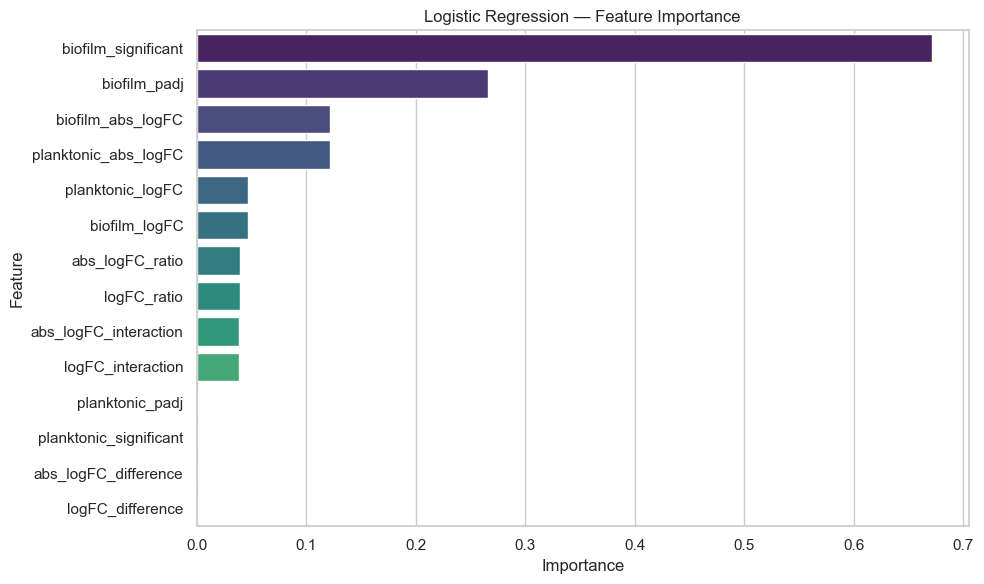

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title(f"{model_name} — Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [25]:
bio_interpret = pd.DataFrame({
    "Feature": importance_df["feature"],
    "Interpretation": [
        "Biofilm log2 fold change — magnitude of induction",
        "Biofilm adjusted p-value — statistical confidence",
        "Planktonic log2 fold change — magnitude of induction",
        "Planktonic adjusted p-value — statistical confidence",
        "Absolute biofilm fold change — strength of signal",
        "Absolute planktonic fold change — strength of signal",
        "Binary: significant in biofilm DESeq2",
        "Binary: significant in planktonic DESeq2",
        "Interaction between biofilm and planktonic logFC",
        "Interaction between absolute logFC values",
        "Difference between biofilm and planktonic logFC",
        "Difference between absolute logFC values",
        "Ratio of biofilm to planktonic logFC",
        "Ratio of absolute logFC values"
    ]
})

bio_interpret


,Feature,Interpretation
6,biofilm_significant,Biofilm log2 fold change — magnitude of induction
1,biofilm_padj,Biofilm adjusted p-value — statistical confidence
4,biofilm_abs_logFC,Planktonic log2 fold change — magnitude of ind...
5,planktonic_abs_logFC,Planktonic adjusted p-value — statistical conf...
2,planktonic_logFC,Absolute biofilm fold change — strength of signal
0,biofilm_logFC,Absolute planktonic fold change — strength of ...
13,abs_logFC_ratio,Binary: significant in biofilm DESeq2
12,logFC_ratio,Binary: significant in planktonic DESeq2
9,abs_logFC_interaction,Interaction between biofilm and planktonic logFC
8,logFC_interaction,Interaction between absolute logFC values


In [26]:
importance_df.to_csv("../data/gene_expression/feature_importance_ranked.csv", index=False)
print("Saved feature importance table.")


Saved feature importance table.
